In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv('Train.csv')

df.columns = df.columns.str.strip().str.lower()

print(df.shape)


(1094, 54)


In [25]:
df.head()

,time,sqnum,stnum,state_cb,sqdiff,stdiff,timelastmsg,recentchange,mu1cs,mu2cs,...,mu4voltageanglea,mu4voltageangleb,mu4voltageanglec,threephasecmu4,ied4_ia,ied4_ib,ied4_ic,mu4log,any_relay,class
0,4319,1,2,1,-3,1,319,1,0,0,...,138.78,18.79,-101.19,-0.80,123.94,3.60,-115.93,0,1,Fault
1,6394,1,4,1,-1,1,75,1,0,0,...,-176.72,63.30,-56.69,-1.58,169.19,48.49,-70.63,0,1,Fault
2,7965,1,6,1,0,1,570,1,0,0,...,163.66,43.72,-76.33,0.00,0.00,0.00,0.00,1,1,Fault
3,27258,1,7,1,-19,1,293,1,0,0,...,9.53,-110.41,129.55,0.00,0.00,0.00,0.00,1,1,Fault
4,29376,1,8,1,-1,1,118,1,0,0,...,17.54,-102.43,137.57,-0.23,-2.31,-122.55,117.70,0,1,Fault


In [26]:
print(df.columns)
print(df.info())


Index(['time', 'sqnum', 'stnum', 'state_cb', 'sqdiff', 'stdiff', 'timelastmsg',
       'recentchange', 'mu1cs', 'mu2cs', 'mu3cs', 'mu4cs', 'cs', 'consistency',
       'threephasevsum', 'threephasecsum', 'threephasevmu1',
       'mu1voltageanglea', 'mu1voltageangleb', 'mu1voltageanglec',
       'threephasecurrentmu1', 'mu1currentanglea', 'mu1currentangleb',
       'mu1currentanglec', 'mu1log', 'threephasevmu2', 'mu2voltageanglea',
       'mu2voltageangleb', 'mu2voltageanglec', 'threephasecmu2',
       'mu2currentanglea', 'mu2currentangleb', 'mu2currentanglec', 'mu2log',
       'threephasevmu3', 'mu3voltageanglea', 'mu3voltageangleb',
       'mu3voltageanglec', 'threephasecmu3', 'mu3currentanglea',
       'mu3currentangleb', 'mu3currentanglec', 'mu3log', 'threephasevmu4',
       'mu4voltageanglea', 'mu4voltageangleb', 'mu4voltageanglec',
       'threephasecmu4', 'ied4_ia', 'ied4_ib', 'ied4_ic', 'mu4log',
       'any_relay', 'class'],
      dtype='object')
<class 'pandas.core.frame.DataFr

In [27]:
print(df.describe())

                time        sqnum        stnum     state_cb       sqdiff  \
count    1094.000000  1094.000000  1094.000000  1094.000000  1094.000000   
mean   255613.944241    11.097806    46.014625     0.425046     0.007313   
std    143186.555417    10.097627    25.100197     0.494576    12.697910   
min      1000.000000     1.000000     1.000000     0.000000   -52.000000   
25%    114826.000000     3.000000    22.000000     0.000000    -6.000000   
50%    282935.000000     8.000000    49.000000     0.000000     0.000000   
75%    374933.500000    17.000000    67.000000     1.000000     7.000000   
max    477962.000000    53.000000   100.000000     1.000000    50.000000   

            stdiff  timelastmsg  recentchange        mu1cs        mu2cs  ...  \
count  1094.000000  1094.000000   1094.000000  1094.000000  1094.000000  ...   
mean      0.078611   436.893967      0.000914     0.005484     0.003656  ...   
std      17.024422   325.431371      0.780010     0.073888     0.060384  ..

In [28]:
# Drop useless columns
df = df.drop(columns=['unnamed: 0'], errors='ignore')

# Check missing
print(df.isnull().sum())

# Fill missing (simple)
df = df.fillna(method='ffill')

time                    0
sqnum                   0
stnum                   0
state_cb                0
sqdiff                  0
stdiff                  0
timelastmsg             0
recentchange            0
mu1cs                   0
mu2cs                   0
mu3cs                   0
mu4cs                   0
cs                      0
consistency             0
threephasevsum          0
threephasecsum          0
threephasevmu1          0
mu1voltageanglea        0
mu1voltageangleb        0
mu1voltageanglec        0
threephasecurrentmu1    0
mu1currentanglea        0
mu1currentangleb        0
mu1currentanglec        0
mu1log                  0
threephasevmu2          0
mu2voltageanglea        0
mu2voltageangleb        0
mu2voltageanglec        0
threephasecmu2          0
mu2currentanglea        0
mu2currentangleb        0
mu2currentanglec        0
mu2log                  0
threephasevmu3          0
mu3voltageanglea        0
mu3voltageangleb        0
mu3voltageanglec        0
threephasecm

C:\Users\Subhalaxmi Sahoo\AppData\Local\Temp\ipykernel_25996\357088928.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [29]:
df['class'] = df['class'].map({'Normal':0, 'Attack':1, 'Fault':1})

In [30]:
df = df.drop(columns=['time'])

In [31]:
corr = df.corr(numeric_only=True)
print(corr)

                         sqnum     stnum  state_cb    sqdiff    stdiff  \
sqnum                 1.000000  0.028389 -0.078315  0.628352  0.006438   
stnum                 0.028389  1.000000  0.150658  0.020068  0.338766   
state_cb             -0.078315  0.150658  1.000000  0.051805  0.106754   
sqdiff                0.628352  0.020068  0.051805  1.000000  0.037356   
stdiff                0.006438  0.338766  0.106754  0.037356  1.000000   
timelastmsg           0.049255 -0.142890 -0.196924 -0.080710  0.010018   
recentchange         -0.022430  0.025047  0.788744  0.015610  0.104306   
mu1cs                -0.073070 -0.020763 -0.063850 -0.082931  0.049116   
mu2cs                -0.053105 -0.051345 -0.052086 -0.052537 -0.031429   
mu3cs                      NaN       NaN       NaN       NaN       NaN   
mu4cs                -0.120639 -0.032596 -0.013109 -0.088206  0.053273   
cs                   -0.124116 -0.022894 -0.003631 -0.110534  0.035203   
consistency           0.083410 -0.1553

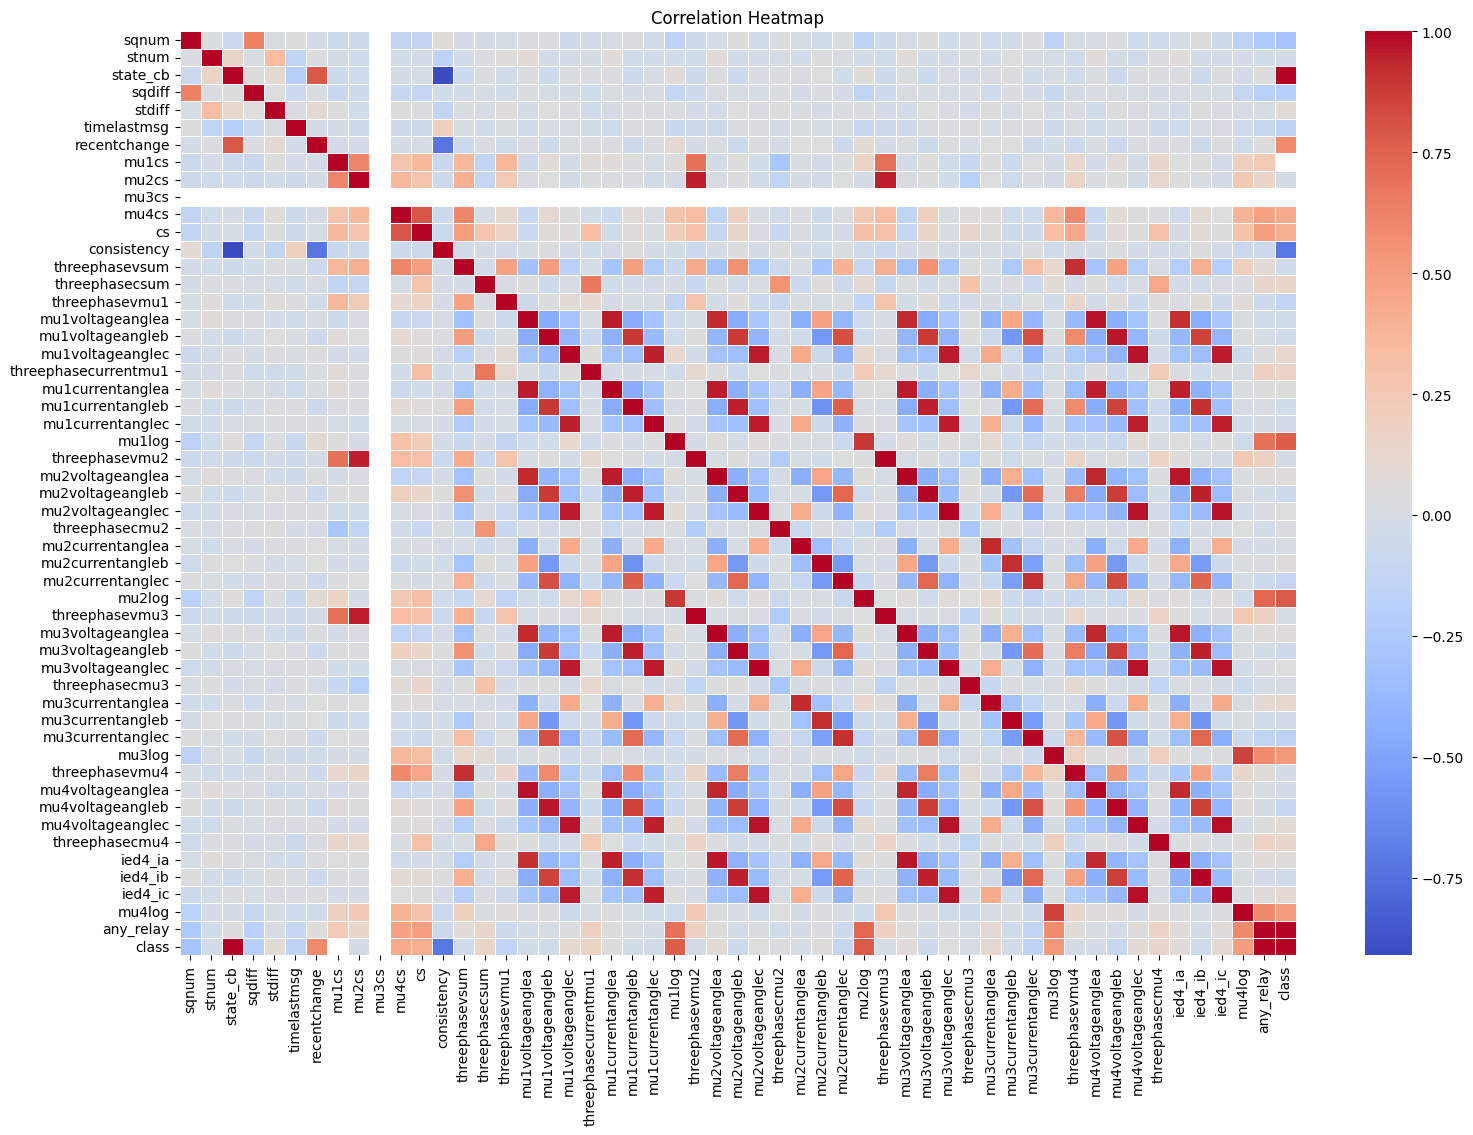

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [33]:
target_corr = corr['class'].sort_values(ascending=False)

print(target_corr)

class                   1.000000
state_cb                1.000000
any_relay               1.000000
mu2log                  0.783523
mu1log                  0.767491
recentchange            0.582580
mu3log                  0.524544
mu4log                  0.501694
mu4cs                   0.435124
cs                      0.422316
threephasecurrentmu1    0.160288
threephasecsum          0.142096
threephasecmu4          0.134003
mu1voltageanglec        0.116071
mu3currentanglea        0.109705
ied4_ic                 0.098481
mu4voltageanglec        0.086397
stdiff                  0.082726
mu3voltageanglea        0.073994
mu2voltageanglea        0.073984
ied4_ia                 0.062140
mu2currentangleb        0.052692
mu1currentanglea        0.046655
mu3voltageanglec        0.043466
mu2voltageanglec        0.043441
threephasecmu2          0.031607
mu2currentanglea        0.005324
threephasecmu3          0.003054
threephasevmu3         -0.004344
threephasevmu2         -0.010794
mu2cs     

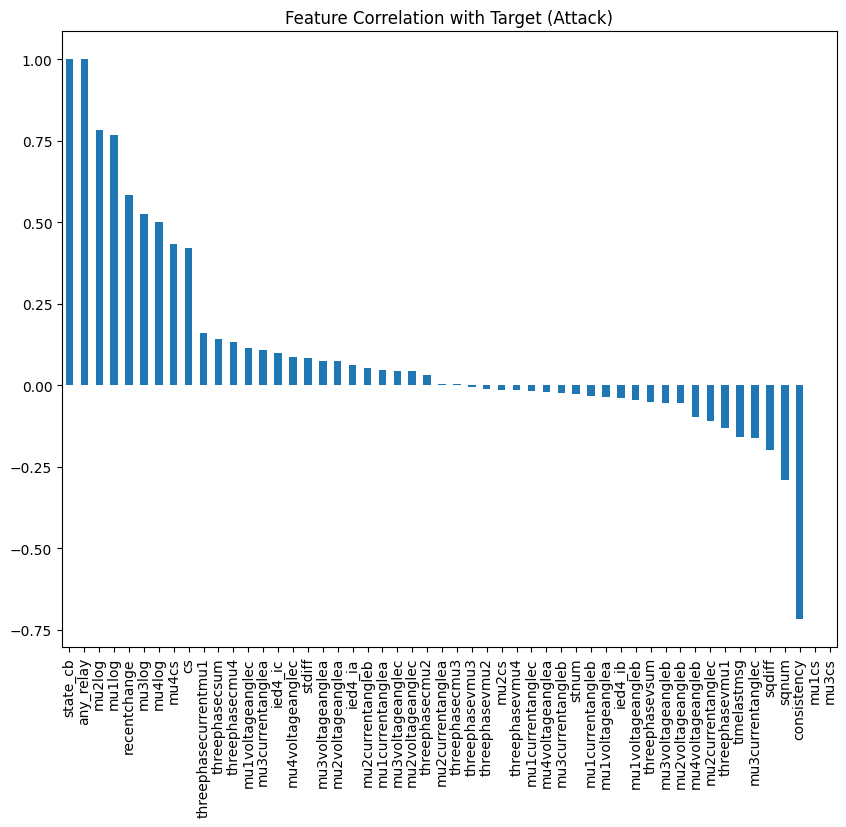

In [34]:
plt.figure(figsize=(10,8))
target_corr.drop('class').plot(kind='bar')
plt.title("Feature Correlation with Target (Attack)")
plt.show()

In [35]:
df['comm_anomaly'] = df['sqdiff'].abs() + df['timelastmsg']
df['state_instability'] = df['stdiff'] + df['recentchange']
df['seq_attack_score'] = df['sqdiff'] * df['recentchange']
df['consistency_attack'] = 1 - df['consistency']

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

important_cols = [
    'sqdiff','stdiff','timelastmsg','recentchange',
    'consistency','any_relay',
    'threephasevmu1','threephasecmu1',
    'threephasevmu2','threephasecmu2',
    'threephasevmu3','threephasecmu3',
    'threephasevmu4','threephasecmu4',
    'class'
]

plt.figure(figsize=(12,8))
sns.heatmap(df[important_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Clean Correlation Heatmap")
plt.show()

KeyError: "['threephasecmu1'] not in index"

<Figure size 1200x800 with 0 Axes>

In [23]:
voltage_cols = [col for col in df.columns if 'threephasevmu' in col.lower()]
current_cols = [col for col in df.columns if 'threephasec' in col.lower() and 'mu' in col.lower()]

print("Voltage:", voltage_cols)
print("Current:", current_cols)

Voltage: ['threephasevmu1', 'threephasevmu2', 'threephasevmu3', 'threephasevmu4']
Current: ['threephasecurrentmu1', 'threephasecmu2', 'threephasecmu3', 'threephasecmu4']


In [22]:
df['avg_voltage'] = df[
    ['threePhaseVMU1','threePhaseVMU2','threePhaseVMU3','threePhaseVMU4']
].mean(axis=1)

df['avg_current'] = df[
    ['threePhaseCMU1','threePhaseCMU2','threePhaseCMU3','threePhaseCMU4']
].mean(axis=1)

KeyError: "None of [Index(['threePhaseVMU1', 'threePhaseVMU2', 'threePhaseVMU3', 'threePhaseVMU4'], dtype='object')] are in the [columns]"